In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('NYC311data.csv')
print(df.head())
print(df.info())
print(df.shape)
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Rows after removing duplicates:", df.shape)
print(df.columns)

   Unique Key            Created Date    Closed Date Agency  \
0    32310363  12/31/2015 11:59:45 PM  01-01-16 0:55   NYPD   
1    32309934  12/31/2015 11:59:44 PM  01-01-16 1:26   NYPD   
2    32309159  12/31/2015 11:59:29 PM  01-01-16 4:51   NYPD   
3    32305098  12/31/2015 11:57:46 PM  01-01-16 7:43   NYPD   
4    32306529  12/31/2015 11:56:58 PM  01-01-16 3:24   NYPD   

                       Agency Name           Complaint Type  \
0  New York City Police Department  Noise - Street/Sidewalk   
1  New York City Police Department         Blocked Driveway   
2  New York City Police Department         Blocked Driveway   
3  New York City Police Department          Illegal Parking   
4  New York City Police Department          Illegal Parking   

                     Descriptor    Location Type  Incident Zip  \
0              Loud Music/Party  Street/Sidewalk       10034.0   
1                     No Access  Street/Sidewalk       11105.0   
2                     No Access  Street/Side

In [7]:
df['Created Date'] = pd.to_datetime(
    df['Created Date'],
    errors='coerce'
)

df['Closed Date'] = pd.to_datetime(
    df['Closed Date'],
    errors='coerce'
)

print(df[['Created Date','Closed Date']].head())

         Created Date         Closed Date
0 2015-12-31 23:59:45 2016-01-01 00:55:00
1 2015-12-31 23:59:44 2016-01-01 01:26:00
2 2015-12-31 23:59:29 2016-01-01 04:51:00
3 2015-12-31 23:57:46 2016-01-01 07:43:00
4 2015-12-31 23:56:58 2016-01-01 03:24:00


In [8]:
df['Resolution_Delay'] = (
    df['Closed Date'] - df['Created Date']
).dt.days
print(df[['Created Date',
          'Closed Date',
          'Resolution_Delay']].head())

         Created Date         Closed Date  Resolution_Delay
0 2015-12-31 23:59:45 2016-01-01 00:55:00               0.0
1 2015-12-31 23:59:44 2016-01-01 01:26:00               0.0
2 2015-12-31 23:59:29 2016-01-01 04:51:00               0.0
3 2015-12-31 23:57:46 2016-01-01 07:43:00               0.0
4 2015-12-31 23:56:58 2016-01-01 03:24:00               0.0


In [9]:
df['Complaint Type'] = (
    df['Complaint Type']
    .str.lower()
    .str.strip()
)

print(df['Complaint Type'].head())

0    noise - street/sidewalk
1           blocked driveway
2           blocked driveway
3            illegal parking
4            illegal parking
Name: Complaint Type, dtype: object


In [10]:
severity_map = {
    'blocked driveway': 3,
    'illegal parking': 2,
    'noise - street/sidewalk': 1
}
df['Severity_Score'] = df['Complaint Type'].map(severity_map)
print(df[['Complaint Type','Severity_Score']].head())

            Complaint Type  Severity_Score
0  noise - street/sidewalk             1.0
1         blocked driveway             3.0
2         blocked driveway             3.0
3          illegal parking             2.0
4          illegal parking             2.0


In [11]:
print("Total Complaints:", len(df))

Total Complaints: 300698


In [12]:
resolved = df[df['Status'].str.lower() == 'closed']
print("Resolved Complaints:", len(resolved))

Resolved Complaints: 298471


In [13]:
pending = len(df) - len(resolved)
print("Pending Complaints:", pending)
resolution_rate = (len(resolved) / len(df)) * 100
print("Resolution Rate:", round(resolution_rate,2), "%")

Pending Complaints: 2227
Resolution Rate: 99.26 %


In [14]:
print("Average Resolution Time:",
      round(df['Resolution_Delay'].mean(), 2),
      "days")

Average Resolution Time: 0.02 days


In [15]:
high_priority_complaints = len(
    df[df['Severity_Score'] == 3]
)
print("High Priority Complaints:", high_priority_complaints)

High Priority Complaints: 77044


In [16]:
citizen_satisfaction_score = resolution_rate
print("Citizen Satisfaction Score:", round(citizen_satisfaction_score, 2))

Citizen Satisfaction Score: 99.26


In [17]:
print("\nComplaint Hotspot Zones")
print(df['Borough'].value_counts().head(5))



Complaint Hotspot Zones
Borough
BROOKLYN         98307
QUEENS           80641
MANHATTAN        66131
BRONX            40702
STATEN ISLAND    12343
Name: count, dtype: int64


In [18]:
department_performance = (
    df.groupby('Agency')['Resolution_Delay']
      .mean()
      .sort_values()
)

print("\nDepartment Performance Score")
print(department_performance)



Department Performance Score
Agency
NYPD    0.016042
Name: Resolution_Delay, dtype: float64


In [19]:
zone_complaints = df['Borough'].value_counts()
print(zone_complaints)

Borough
BROOKLYN         98307
QUEENS           80641
MANHATTAN        66131
BRONX            40702
STATEN ISLAND    12343
Unspecified       2574
Name: count, dtype: int64


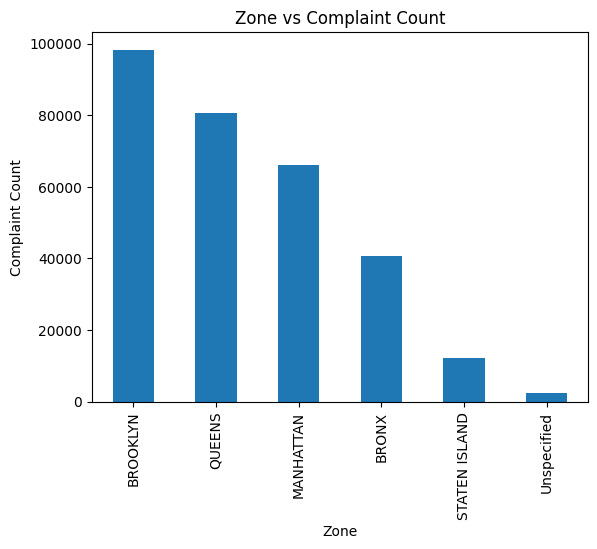

In [20]:
import matplotlib.pyplot as plt
zone_complaints.plot(kind='bar')
plt.title('Zone vs Complaint Count')
plt.xlabel('Zone')
plt.ylabel('Complaint Count')
plt.show()

Complaint Type
animal in a park       14.000000
derelict vehicle        0.073971
graffiti                0.061947
panhandling             0.026230
animal abuse            0.024459
illegal parking         0.014920
blocked driveway        0.014842
homeless encampment     0.011096
traffic                 0.010454
drinking                0.010196
Name: Resolution_Delay, dtype: float64


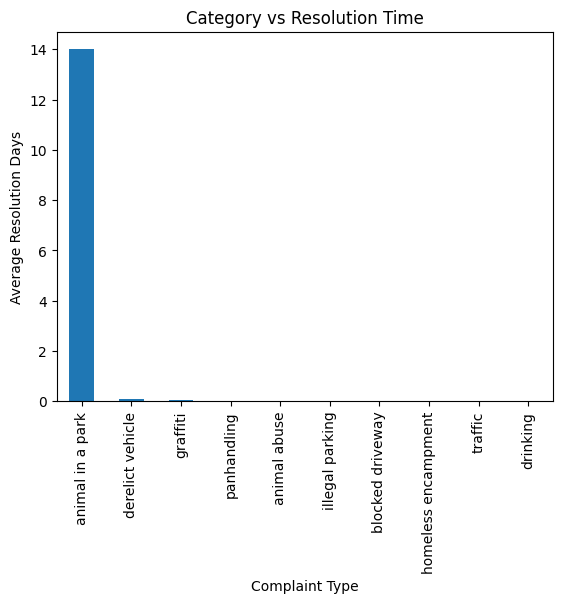

In [21]:
category_resolution = (
    df.groupby('Complaint Type')['Resolution_Delay']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
print(category_resolution)
category_resolution.plot(kind='bar')
plt.title('Category vs Resolution Time')
plt.xlabel('Complaint Type')
plt.ylabel('Average Resolution Days')
plt.show()

Agency
NYPD    0.016042
Name: Resolution_Delay, dtype: float64


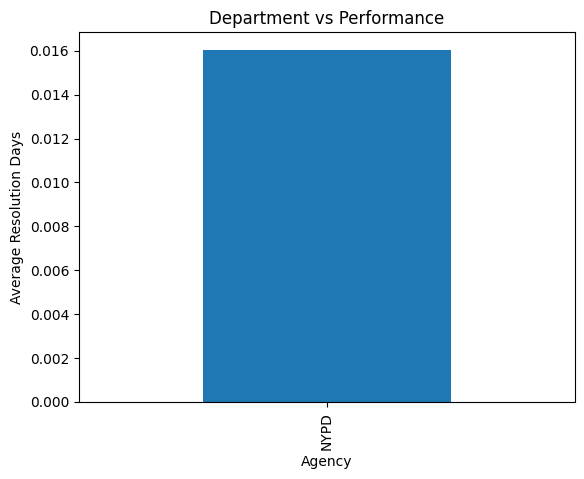

In [22]:
department_performance = (
    df.groupby('Agency')['Resolution_Delay']
      .mean()
      .sort_values()
)
print(department_performance)
department_performance.plot(kind='bar')
plt.title('Department vs Performance')
plt.xlabel('Agency')
plt.ylabel('Average Resolution Days')
plt.show()

Month
3      2471
4     27305
5     36437
6     35315
7     34888
8     34956
9     35427
10    32605
11    30773
12    30521
Name: Unique Key, dtype: int64


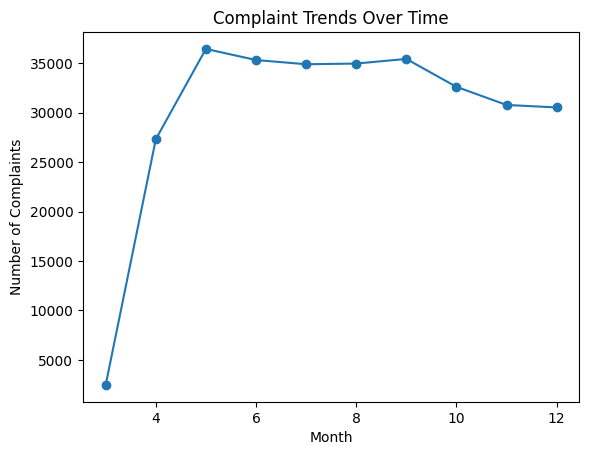

In [23]:
df['Month'] = df['Created Date'].dt.month
monthly_trend = (
    df.groupby('Month')['Unique Key']
      .count()
)
print(monthly_trend)
monthly_trend.plot(kind='line', marker='o')
plt.title('Complaint Trends Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.show()

Severity_Score
1.0    0.009319
2.0    0.014920
3.0    0.014842
Name: Resolution_Delay, dtype: float64


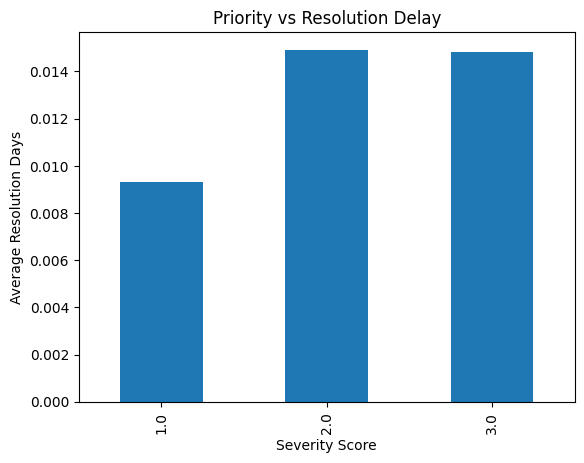

In [24]:
priority_delay = (
    df.groupby('Severity_Score')['Resolution_Delay']
      .mean()
)
print(priority_delay)
priority_delay.plot(kind='bar')
plt.title('Priority vs Resolution Delay')
plt.xlabel('Severity Score')
plt.ylabel('Average Resolution Days')
plt.show()

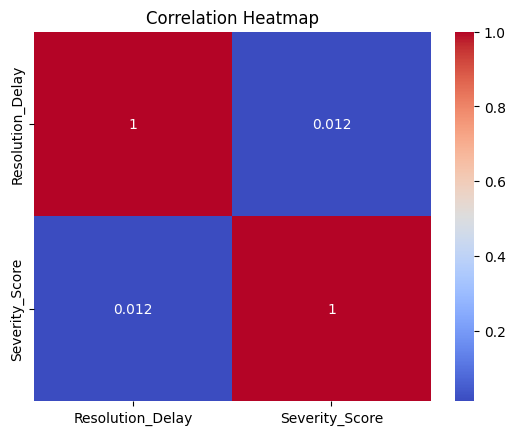

In [25]:
import seaborn as sns
numeric_df = df[['Resolution_Delay','Severity_Score']]
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

In [26]:
import folium
map_df = df.dropna(subset=['Latitude', 'Longitude'])
city_map = folium.Map(
    location=[40.7128, -74.0060],
    zoom_start=10
)
for _, row in map_df.head(1000).iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=2
    ).add_to(city_map)
city_map